# Retail Sales Exploratory Data Analysis (EDA)

## Objective
The objective of this project is to analyze retail sales data and extract business insights related to sales trends, profitability, product performance, and regional distribution before dashboard visualization in Power BI.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries imported successfully!")

Libraries imported successfully!


In [21]:
df = pd.read_csv("../data/SampleSuperstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [22]:
print("Dataset Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (9994, 21)

Columns:

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Data Types:

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [23]:
missing_values = df.isnull().sum()

print("Missing Values:\n")
print(missing_values)

Missing Values:

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [24]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)
df.describe()

Duplicate Rows: 0


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [25]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")

df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True, errors="coerce")

print("Date conversion successful!")

Date conversion successful!


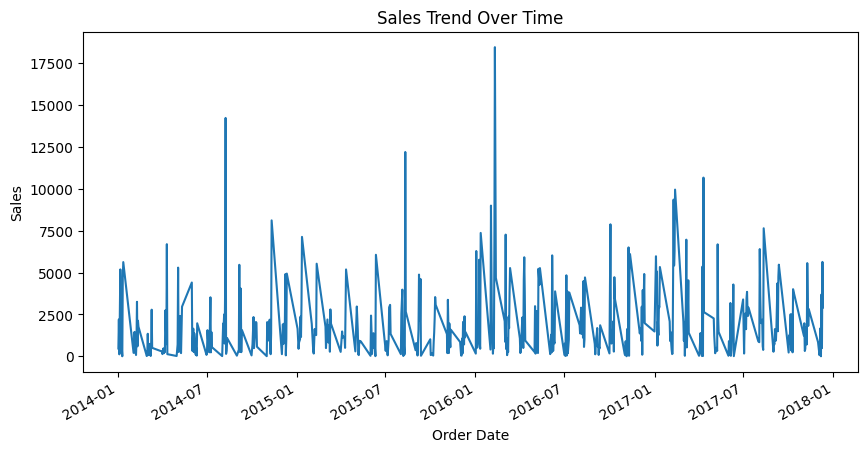

In [26]:
sales_trend = df.groupby("Order Date")["Sales"].sum()

sales_trend.plot()

plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.savefig("../Insights/sales-trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

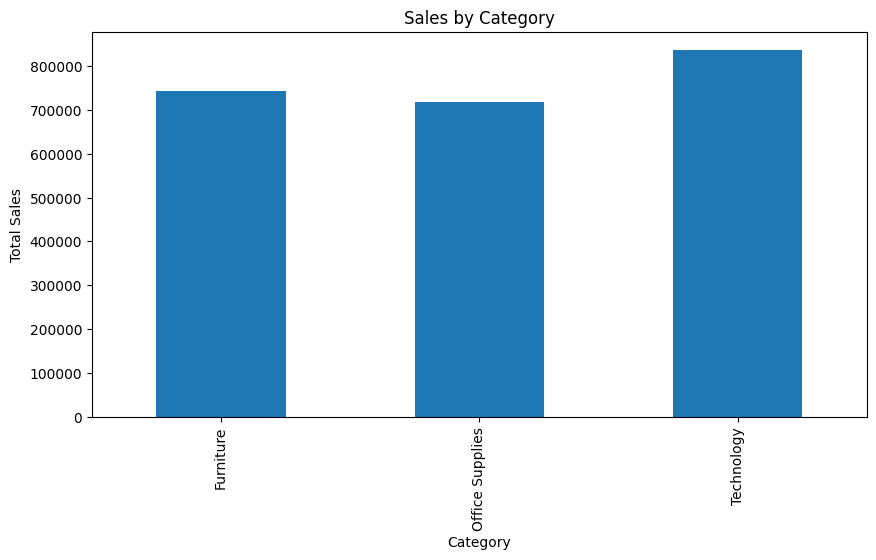

In [27]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.savefig("../Insights/Category-sales.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

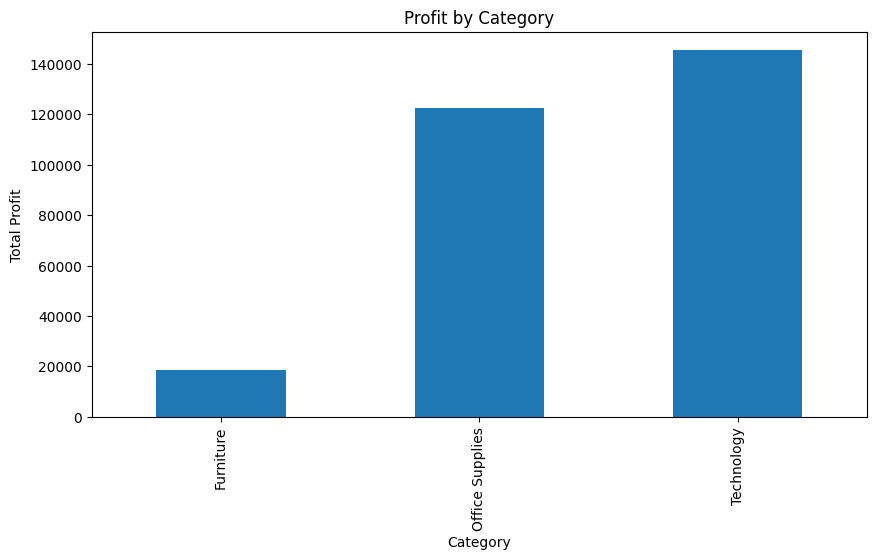

In [28]:
profit_analysis = df.groupby("Category")["Profit"].sum()

profit_analysis.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.savefig("../Insights/category-profit.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

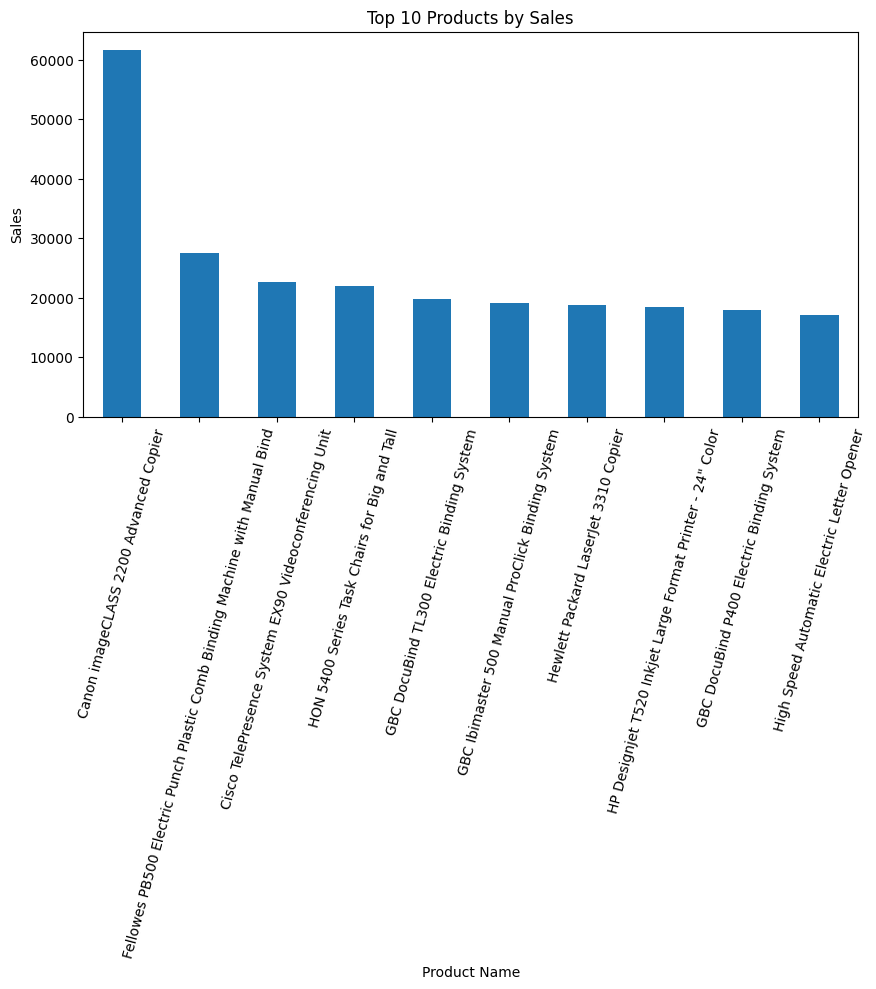

In [29]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Sales")

plt.xticks(rotation=75)

plt.savefig("../Insights/top 10 products.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

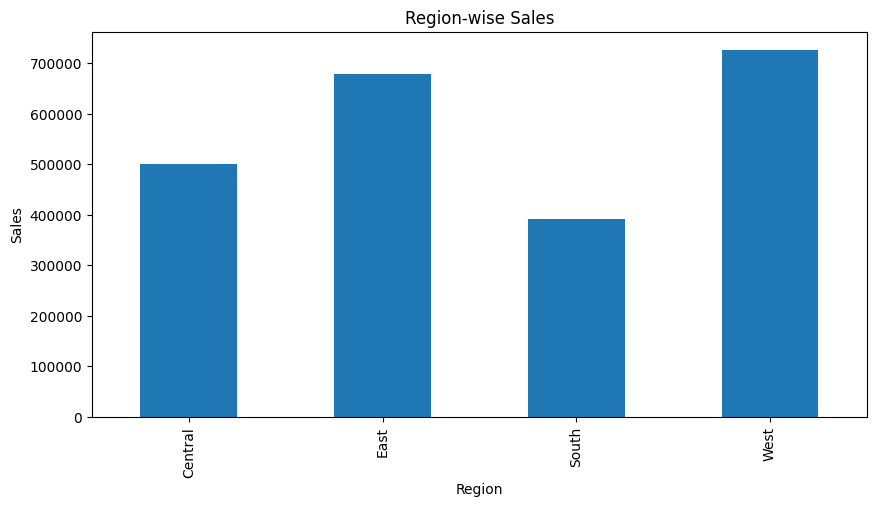

In [30]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar")

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.savefig("../Insights/regional-sales.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [31]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


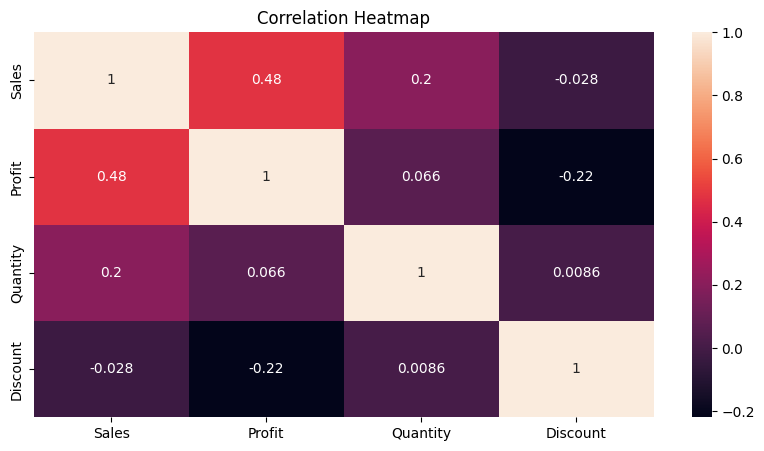

In [32]:
import seaborn as sns

correlation = df[["Sales", "Profit", "Quantity", "Discount"]].corr()

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")

plt.savefig("../Insights/correlation-heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

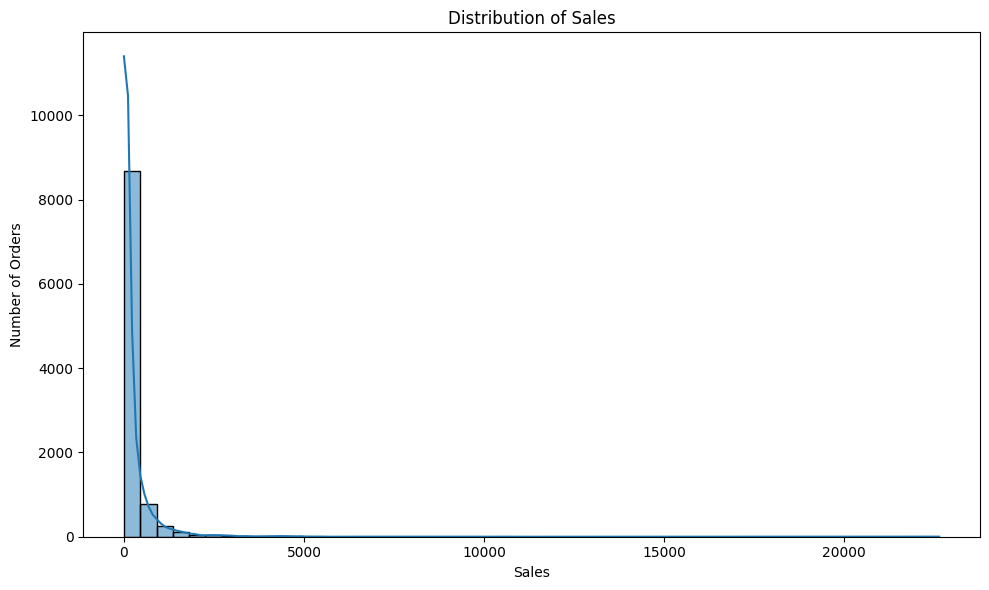

In [34]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Sales"], bins=50, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig("../Insights/sales_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Sales Distribution

The distribution of sales is highly right-skewed, indicating that the majority of customer orders are of relatively low value, while a small number of high-value transactions contribute significantly to overall revenue. This pattern is common in retail businesses where a limited number of premium or bulk purchases account for a disproportionate share of total sales.


### Buisness insights
 Since a small percentage of orders generate a substantial portion of total revenue, the business should focus on identifying and retaining high-value customers while increasing the average order value of smaller purchases through targeted promotions, product bundles, and personalized recommendations.

# Key Insights

- Technology category generated the highest sales revenue.
- West region contributed significantly to overall sales.
- Certain products dominated total revenue contribution.
- Sales trends increased steadily over time.
- Discounts negatively impacted profitability in some cases.